# Turbulent Jet Example

In previous examples I discussed release scenarios involving vapour clouds spreading over a large area, carried by the wind. In those examples the momentum of the jet of fluid was not very important relative to the ambient wind conditions and could be ignored. In this example I am looking at the opposite extreme, a release from a pressure vessel inside a building where the momentum of the jet dominates.

## The Scenario

Consider, for an example, a leak from an acetylene cylinder inside a large building, such as in a warehouse or shop. We imagine, for convenience, that the air within the building is quiescent. For the sake of an example suppose the leak is a 1/4 in. hole, similar in diameter to a typical acetylene hose, and that the operating pressure at that point is 15psig[^1] We are interested in exploring the concentration distribution as the acetylene jets into the air and mixes, with our reference concentration of interest being half the LEL of 2.5%(vol).

[^1]: From CGA G-1 2009 the safe operating pressure of an acetylene system

In [1]:
#hide

# libraries used, with the functions used indicated

using Unitful           # ustrip()
using Roots             # find_zero()
using Plots             # plot()
using HCubature

In [2]:
inch = ustrip(u"m", 1u"inch") # unit conversion inch->m
psi = ustrip(u"Pa", 1u"psi")  # unit conversion psi->Pa

dₕ = 0.25inch   # Diameter of the hole, in m

pₐ= 14.7psi     # atmospheric pressure in Pa absolute
p = 15psi + pₐ  # pressure of the acetylene in Pa absolute
Tᵣ= 25 + 273.15 # the release temperature in K

298.15

In [3]:
R = 8.31446261815324  # universal gas constant, J/mol/K

MW = 26.038  # molar mass of acetylene, kg/kmol
LEL = 0.025  # Lower explosive limit, vol/vol
μ = 10.4e-6  # viscosity of acetylene gas at 300K, Pa*s
ρ(T) = (pₐ*MW)/(R*T)/1000 # density of acetylene, ideal gas law, kg/m^3

MWₐᵢᵣ = 28.960  # molar weight air, kg/kmol
ρₐ(T) = (pₐ*MWₐᵢᵣ)/(R*T)/1000 # density of air, ideal gas law, kg/m^3


ρₐ (generic function with 1 method)

## The Release Rate

The simplest way of estimating the release rate is using the Bernoulli equation for a jet[^2]

$$ Q_0 = c_d A_h \sqrt{ 2 \left( p - p_a \over \rho \right) } = c_d {{\pi \over 4} d_h^2} \sqrt{ 2 \left( p - p_a \over \rho \right) } $$

Where $Q_0$ is the volumetric flow of acetylene discharged through the hole (in m³/s), $c_d$ is the discharge coefficient which can be assumed to be 0.61[^3], and the rest are as defined earlier. I am assuming, here, that the hole is circular for simplicity.

[^2]: 

[^3]: 

In [4]:
cd = 0.61
Q₀ = cd * π/4 * dₕ^2 * √( 2*(p - pₐ)/ρ(Tᵣ) )

0.008515297292624617

## Jet Behaviour

To model the concentration profile I am going to assume a turbulent jet, from a circular hole, mixing with air. In this case the density of air and acetylene are similar and so a simple turbulent jet model is appropriate. If there was a significant difference in densities then a density correction would be needed, however for many applications "close" means a ratio of ambient to jet densities between[^4]

$$ \frac{1}{4} \le { \rho_{a} \over \rho_{j} } \le 4 $$

Where subscript *a* indicates the ambient fluid and *j* the jet.

Circular turbulent jets expand by entraining ambient fluid, tracing out a cone defined by a jet angle $\alpha \approx 15-25^\circ$. The mixing layer penetrates into the jet forming the potential cone, inside is pure jet material and outside is mixed. After approximately 6 hole diameters the region is fully developed.[^5]

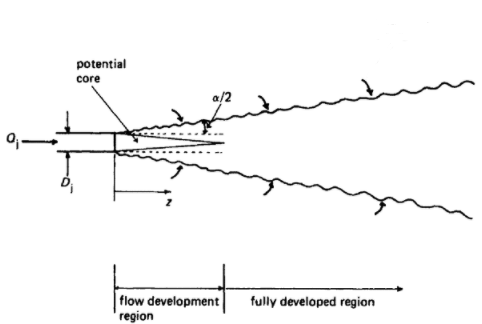

Empirical approximations of the velocity, and concentration, profiles are often given with respect to this jet angle or, equivalently, the slope of line (i.e. $\tan \frac{\alpha}{2}$)

Another important factor is the Reynolds number, the jet is fully turbulent when $Re \gt 2000$, where the Reynolds number is calculated with respect to the initial jet velocity and jet diameter (i.e. the hole diameter)

$$ Re = { \rho u d_h \over \mu } $$

[^4]: Poleshaw, Yury V., Golub, V. V., *Jets*, [Thermopedia](https://www.thermopedia.com/content/903/)

[^5]: Harnby, N., Edwards, M.F., Nienow, A. W., *Mixing in the Process Industries, 2nd Ed.*, Elsevier, 1992

In [5]:
u = Q₀ / (π/4 * dₕ^2)

268.88246631895174

In [6]:
Re = ρ(Tᵣ) * u * dₕ / μ

174774.39626709497

In [7]:
Re > 2000

true

So the jet, in this case, is fully turbulent which guides the choice of models we have available to us.

### Velocity and Concentration distributions

There are many different empirical velocity distributions as well as velocity distributions derived from theories of turbulent mixing available in various references. Mostly of the same general type (gaussian), but parametrized slightly differently. However, in my experience, there are far fewer concentration distributions available, however this is not too critical due to an interesting result in turbulent mass transfer for jets[^6]

$$ { C \over C_{max} } = \left( v_z \over v_{z,max} \right)^{Sc_t} $$

That is, at a given distance *z* away from the hole, the concentration profile is the velocity profile raised to the power $Sc_t$ -- the turbulent Schmidt number. Experimentally this is approximately 0.7. Note also that $C_{max}$ and $v_{z,max}$ are taken at the centerline. Physically this means that the concentration profile, at a given downstream distance, is wider than the velocity distribution; concentration expands more.

[^6]: Bird, R. B., Stewart, W. E., Lightfoot, E. N., *Transport Phenomena, 2nd ed.*, John Wiley & Sons, 2007

A similar way of capturing the same phenomenon that is often seen with empirical velocity distributions is to define a width parameter $b$ and note that the equivalent width for the concentration profile is $1.17b$[^7] and substitute in accordingly.

[^7]: Kutz, M., *Handbook of Environmental Engineering*, John Wiley & Sons, 2018

In this example I am using the empirical concentration given in *Lee's*[^8] for simplicity

$$ {C \over C_0 } = k_2 \left( d_h \over z \right) \left( \rho_z \over \rho_0 \right)^{0.5} \exp \left( - \left( k_3 r \over z \right)^2 \right) $$

Note also the ratio of densities, the density $\rho_z$ is the density of the jet at some distance *z* and it is common to conservatively take this as $\rho_a$, similarly the density $\rho_0$ is the initial jet density and is taken as $\rho_j$

[^8]: Mannan, S., *Lee's Loss Prevention in the Process Industries, 4th ed.*, Elsevier, 2012

The parameters $k_2$ and $k_3$ are empirically derived for the particular jet and $k_2$ is a function of Reynolds number below $ Re < 20000 $ [^9]. The conservative values suggested are *6* and *5* respectively.

[^9]: Long, V.D., *Estimation of the Extent of Hazard Areas Around a Vent*, Chem. Process Hazard, II, 6, 1963

In [8]:
function C(r, z; C₀=1.0, k₂=6, k₃=5, d=dₕ, ρz=ρₐ(Tᵣ), ρ₀=ρ(Tᵣ))
    C = C₀ * k₂ * (d/z) * √(ρz/ρ₀) * exp(-(k₃*r/z)^2)
end

C (generic function with 1 method)

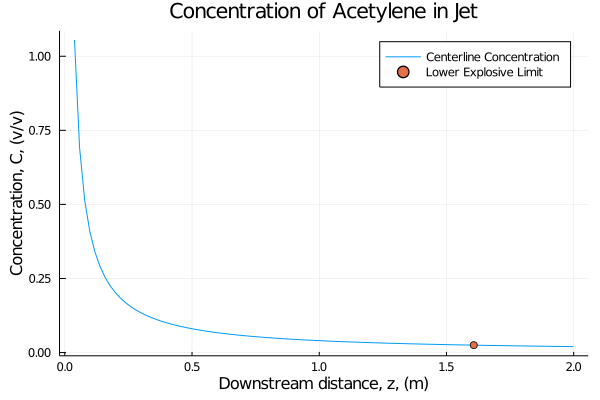

In [9]:
#hide

zs = 6*dₕ:0.02:2
Cs = C.(0, zs)

z_lel = find_zero(z -> C(0, z) - LEL, 1)

plot(zs, Cs, lab="Centerline Concentration")
plot!([z_lel], [LEL], seriestype=:scatter, lab="Lower Explosive Limit")

plot!(title="Concentration of Acetylene in Jet",
      ylabel="Concentration, C, (v/v)",
      xlabel="Downstream distance, z, (m)")

At this point it is worth pointing out that the model of the jet is independent of the discharge rate. The concentration profile is only a function of the hole diameter and the fluid density. The velocity in the jet, and the amount of air entrained in the jet, do depend strongly on the initial discharge rate but in such a way that the concentration does not. As the jet velocity increases proportionally more air is entrained and the concentration profile remains constant.

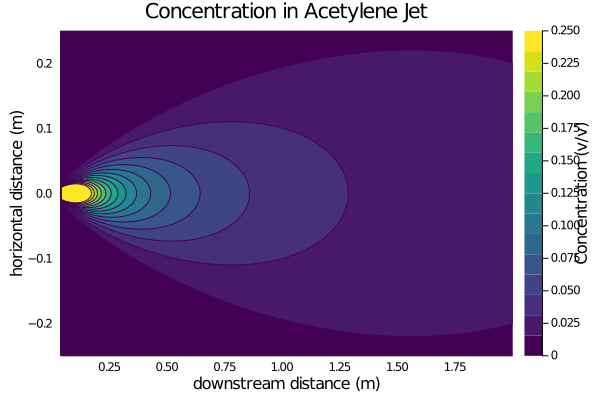

In [10]:
# hide

ys = -0.25:0.0025:0.25

contour(zs, ys, (z,y) -> C(y,z),
        c=:viridis, fill=true,
        clim=(0,0.25), colorbar_title="Concentration (v/v)",
        xlabel="downstream distance (m)", ylabel="horizontal distance (m)",
        title="Concentration in Acetylene Jet")

## Explosive Mass

Now that we have a model of the jet, showing the concentration of acetylene, the most relevant parameter we would want to know is the explosive mass such that some blast modeling could be done.

The most obvious way to do this is to integrate over the jet, using cylindrical coordinates for convenience

$$ m_e = \int \rho_j C(r,z) dV = 2\pi \rho_j \int_{0}^{\infty} \int_{0}^{\infty} C(r,z) r dr dz $$

Except that we define the explosive mass to be the volume where $ C > \frac{1}{2} LEL $. A lazy way to do this is to define a function that equals $C$ if it is $ \gt \frac{1}{2} LEL $ and zero otherwise.

The potential core region is poorly described by this model, and the closer to the origin of the jet the more unphysical the results: giving concentrations greater than 100% and being undefined completely at the origin. One way of hand waving this away is to chop off any concentrations above 100%.

In [12]:
function f(v; lim=0.5*LEL)
    r, z = v
    conc = C(r,z)
    
    if z == 0
        result = 1.0
    elseif conc > 1.0
        result = 1.0
    elseif conc < lim
        result = 0.0
    else
        result = conc
    end
    
    return r*result
end

f (generic function with 1 method)

Integrating over some plausible bounds, taken by looking at the plots above, gives the volume of acetylene.

In [13]:
I, err = hcubature(f, [0, 0], [0.25, 1.7], atol = 1e-8)

(0.0007367693893152862, 9.999943298543674e-9)

Which can be plugged into the equation to calculate the final explosive mass.

In [14]:
mₑ = 2*π*ρ(Tᵣ)*I

0.004928177978823539

To give a sense of how much this is, the explosive mass is equivalent to ~0.5s of discharge at the steady state discharge rate.

In [15]:
mₑ / (ρ(Tᵣ)*Q₀)

0.5436402796805507

## Conclusions

Turbulent jet mixing is a much simpler model for estimating releases, especially when using empirical models, compared to models for plumes influences by buoyancy and wind. There are much fewer parameters that need to be estimated.

One big weakness to the model as presented here is that it does not take into account the enclosed space. If the assumption is that the warehouse is large and ignition sources are numerous then that likely doesn't matter, the acetylene leak will ignite before it has a chance to accumulate. However it will grossly underestimate the potential explosive mass that could develop as the acetylene disperses through the air of warehouse, since the model presumes the ambient air has no acetylene in it and is effectively infinite in extent.

This limitation would, for me, motivate exploring more detailed models of gas build up in enclosed spaces